# CLASS – Dataset Bàsic (sense anotació VEP)
Aquest notebook entrena els sis models de classificació per a la 
predicció de conflictes entre laboratoris (CLASS) sobre el dataset 
bàsic, que no inclou les anotacions funcionals VEP.

> **Nota:** els sis models, els hiperparàmetres i el pipeline de preprocessament 
> són idèntics als del notebook `class_annotated`. L'única diferència és el conjunt 
> de variables d'entrada (sense les anotacions funcionals VEP). Per a la descripció 
> detallada de cada model, vegeu aquell notebook.

## Imports

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.sparse
import shap

from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import plot_tree

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"sklearn\.utils\.extmath"
)

/Users/eliag/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Càrrega i preparació del dataset

In [2]:
# Crear dataset bàsic (sense columnes VEP)
df = pd.read_csv('../data/raw/clinvar_conflicting.csv',
                 dtype={'CHROM': str})

# Columnes VEP a eliminar per crear el dataset bàsic
vep_cols = [
    "Allele", "Consequence", "IMPACT", "SYMBOL", "Feature_type", "Feature",
    "BIOTYPE", "EXON", "INTRON", "cDNA_position", "CDS_position",
    "Protein_position", "Amino_acids", "Codons", "STRAND", "BAM_EDIT",
    "SIFT", "PolyPhen", "LoFtool", "CADD_PHRED", "CADD_RAW", "BLOSUM62"
]

# Crear dataset bàsic eliminant les columnes VEP
df_basic = df.drop(columns=[c for c in vep_cols if c in df.columns])
df_basic.to_csv("../data/raw/clinvar_class_basic.csv", index=False)

print("Annotated shape:", df.shape)
print("Basic shape:    ", df_basic.shape)

/var/folders/tl/5pdn6vld70l0ndj9lvltyvxw0000gn/T/ipykernel_3899/3082908282.py:2: DtypeWarning: Columns (38,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/clinvar_conflicting.csv',


Annotated shape: (65188, 46)
Basic shape:     (65188, 24)


## Distribució de CLASS

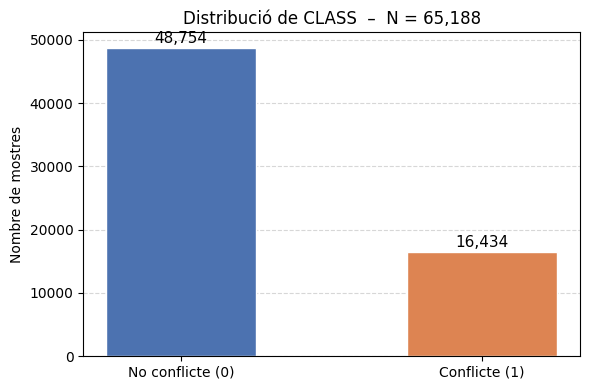

CLASS
0    48754
1    16434


In [3]:
counts = df_basic["CLASS"].value_counts().sort_index()
labels = ["No conflicte (0)", "Conflicte (1)"]
colors = ["#4C72B0", "#DD8452"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 300, f"{v:,}", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Nombre de mostres")
ax.set_title(f"Distribució de CLASS  –  N = {len(df_basic):,}")
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(counts.to_string())

## Partició de dades i Preprocessat (Bàsic)

In [4]:
TARGET_COL = "CLASS"
RANDOM_STATE = 42
TEST_SIZE = 0.10

X_b = df_basic.drop(columns=[TARGET_COL])
y_b = df_basic[TARGET_COL]

# Dividir en train+val i test
X_train_val_basic, X_test_basic, y_train_val_basic, y_test_basic = train_test_split(
    X_b, y_b,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_b,
)

# Eliminar columnes amb alt percentatge de valors faltants
cols_high_missing = [
    'MOTIF_SCORE_CHANGE', 'HIGH_INF_POS', 'MOTIF_POS', 'MOTIF_NAME',
    'DISTANCE', 'SSR', 'CLNSIGINCL', 'CLNDISDBINCL', 'CLNDNINCL'
]

# Eliminar aquestes columnes tant del train+val com del test 
X_train_val_basic = X_train_val_basic.drop(columns=cols_high_missing, errors="ignore")
X_test_basic      = X_test_basic.drop(columns=cols_high_missing, errors="ignore")

num_cols_b = X_train_val_basic.select_dtypes(include=np.number).columns.tolist()
cat_cols_b = X_train_val_basic.select_dtypes(exclude=np.number).columns.tolist()

# Preprocessing pipeline per al dataset bàsic
numeric_transformer_b = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer_b = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])
# Combinar els transformers en un ColumnTransformer
preprocessor_basic = ColumnTransformer(transformers=[
    ("num", numeric_transformer_b, num_cols_b),
    ("cat", categorical_transformer_b, cat_cols_b),
])

print("X_train_val_basic shape:", X_train_val_basic.shape)
print("X_test_basic shape:", X_test_basic.shape)

X_train_val_basic shape: (58669, 14)
X_test_basic shape: (6519, 14)


# Entrenament dels models

## LinearSVC (Bàsic)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 0.01, 'model__class_weight': None}
Millor CV ROC AUC:  0.7397

Test ROC AUC: 0.7373
Confusion matrix:
[[4138  738]
 [ 980  663]]


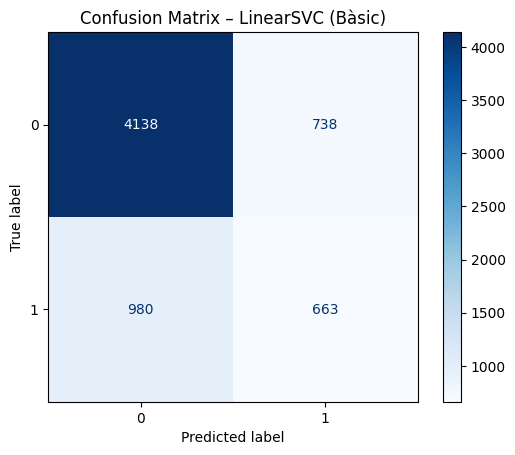

In [5]:
# Model base
linear_svm_b = LinearSVC(
    random_state=42,
    max_iter=100000,
    dual=False,
    loss="squared_hinge"
)

# Pipeline preprocessament + model
pipeline_linsvm_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", linear_svm_b)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_svm_basic = GridSearchCV(
    estimator=pipeline_linsvm_basic,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_svm_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_svm_basic.best_params_}")
print(f"Millor CV ROC AUC:  {grid_svm_basic.best_score_:.4f}")

best_svm_basic = grid_svm_basic.best_estimator_
svm_scores_basic = best_svm_basic.decision_function(X_test_basic)
y_pred_svm_basic = best_svm_basic.predict(X_test_basic)
auc_svm_basic = roc_auc_score(y_test_basic, svm_scores_basic)
cm_svm_basic = confusion_matrix(y_test_basic, y_pred_svm_basic)

print(f"\nTest ROC AUC: {auc_svm_basic:.4f}")
print(f"Confusion matrix:\n{cm_svm_basic}")

ConfusionMatrixDisplay(confusion_matrix=cm_svm_basic).plot(cmap="Blues")
plt.title("Confusion Matrix – LinearSVC (Bàsic)")
plt.show()

## Ridge logistic regression (Bàsic)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 0.1, 'model__class_weight': None}
Millor CV ROC AUC:  0.7459

Test ROC AUC: 0.7432
Confusion matrix:
[[3667 1209]
 [ 710  933]]


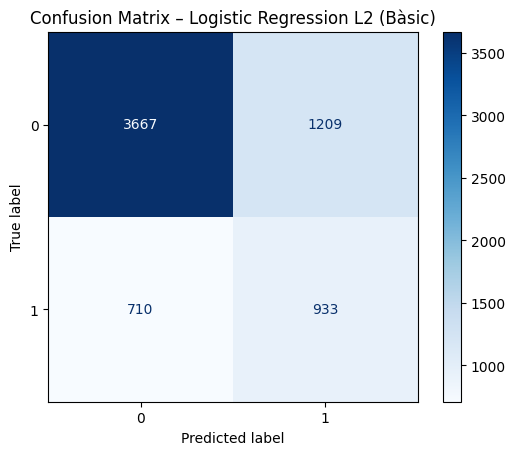

In [6]:
# Model base
logreg_l2_b = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

# Pipeline preprocessament + model
pipeline_logreg_l2_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", logreg_l2_b)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_l2_basic = GridSearchCV(
    estimator=pipeline_logreg_l2_basic,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_l2_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_l2_basic.best_params_}")
print(f"Millor CV ROC AUC:  {grid_l2_basic.best_score_:.4f}")

best_l2_basic = grid_l2_basic.best_estimator_
l2_proba_basic = best_l2_basic.predict_proba(X_test_basic)[:, 1]
y_pred_l2_basic = best_l2_basic.predict(X_test_basic)
auc_l2_basic = roc_auc_score(y_test_basic, l2_proba_basic)
cm_l2_basic = confusion_matrix(y_test_basic, y_pred_l2_basic)

print(f"\nTest ROC AUC: {auc_l2_basic:.4f}")
print(f"Confusion matrix:\n{cm_l2_basic}")

ConfusionMatrixDisplay(confusion_matrix=cm_l2_basic).plot(cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression L2 (Bàsic)")
plt.show()

## Lasso logistic regression (Bàsic)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__C': 1.0, 'model__class_weight': None}
Millor CV ROC AUC:  0.7440

Test ROC AUC: 0.7425
Confusion matrix:
[[4293  583]
 [1085  558]]


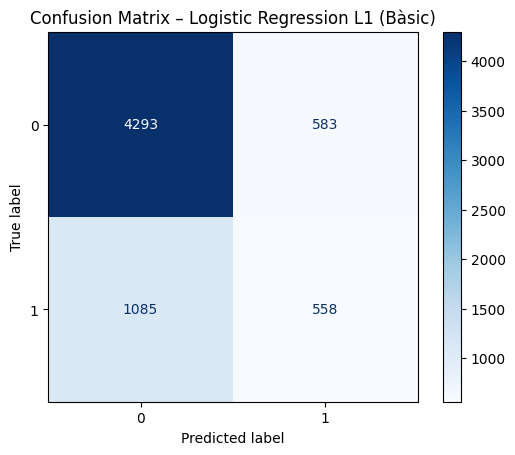

In [7]:
# Model base
logreg_l1_b = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

# Pipeline preprocessament + model
pipeline_logreg_l1_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", logreg_l1_b)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "model__class_weight": [None, "balanced"]
}

grid_l1_basic = GridSearchCV(
    estimator=pipeline_logreg_l1_basic,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_l1_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_l1_basic.best_params_}")
print(f"Millor CV ROC AUC:  {grid_l1_basic.best_score_:.4f}")

best_l1_basic = grid_l1_basic.best_estimator_
l1_proba_basic = best_l1_basic.predict_proba(X_test_basic)[:, 1]
y_pred_l1_basic = best_l1_basic.predict(X_test_basic)
auc_l1_basic = roc_auc_score(y_test_basic, l1_proba_basic)
cm_l1_basic = confusion_matrix(y_test_basic, y_pred_l1_basic)

print(f"\nTest ROC AUC: {auc_l1_basic:.4f}")
print(f"Confusion matrix:\n{cm_l1_basic}")

ConfusionMatrixDisplay(confusion_matrix=cm_l1_basic).plot(cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression L1 (Bàsic)")
plt.show()

## Decision Tree (Bàsic)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Millors paràmetres: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}
Millor CV ROC AUC:  0.7433

Test ROC AUC: 0.7108
Confusion matrix:
[[3602 1274]
 [ 682  961]]


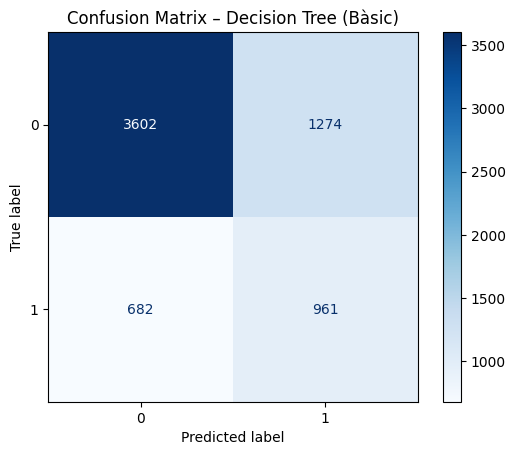

In [8]:
# Model base
dt_b = DecisionTreeClassifier(
    random_state=42
)

# Pipeline preprocessament + model
pipeline_dt_binary_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", dt_b)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid_dt_b = {
    "model__max_depth":         [5, 10, 20, None],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf":  [1, 5, 10],
    "model__class_weight":      [None, "balanced"]
}

grid_dt_binary_basic = GridSearchCV(
    estimator=pipeline_dt_binary_basic,
    param_grid=param_grid_dt_b,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_dt_binary_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_dt_binary_basic.best_params_}")
print(f"Millor CV ROC AUC:  {grid_dt_binary_basic.best_score_:.4f}")

best_dt_basic = grid_dt_binary_basic.best_estimator_
dt_proba_basic = best_dt_basic.predict_proba(X_test_basic)[:, 1]
y_pred_dt_basic = best_dt_basic.predict(X_test_basic)
auc_dt_basic = roc_auc_score(y_test_basic, dt_proba_basic)
cm_dt_basic = confusion_matrix(y_test_basic, y_pred_dt_basic)

print(f"\nTest ROC AUC: {auc_dt_basic:.4f}")
print(f"Confusion matrix:\n{cm_dt_basic}")

ConfusionMatrixDisplay(confusion_matrix=cm_dt_basic).plot(cmap="Blues")
plt.title("Confusion Matrix – Decision Tree (Bàsic)")
plt.show()

## Random Forest (Bàsic)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Millors paràmetres: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.3, 'model__max_depth': 20, 'model__class_weight': None}
Millor CV ROC AUC:  0.7913

Test ROC AUC: 0.7993
Confusion matrix:
[[4682  194]
 [1274  369]]


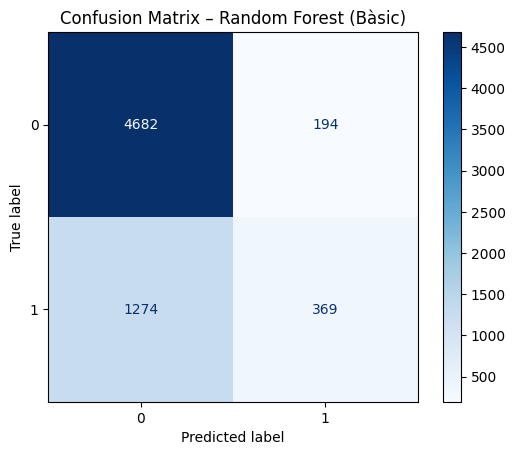

In [9]:
# Model base
rf_b = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Pipeline preprocessament + model
pipeline_rf_binary_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", rf_b)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_dist_rf_b = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 5],
    "model__max_features":      ["sqrt", 0.3],
    "model__class_weight":      [None, "balanced"]
}

random_search_rf_binary_basic = RandomizedSearchCV(
    estimator=pipeline_rf_binary_basic,
    param_distributions=param_dist_rf_b,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)
random_search_rf_binary_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {random_search_rf_binary_basic.best_params_}")
print(f"Millor CV ROC AUC:  {random_search_rf_binary_basic.best_score_:.4f}")

best_rf_basic = random_search_rf_binary_basic.best_estimator_
rf_proba_basic = best_rf_basic.predict_proba(X_test_basic)[:, 1]
y_pred_rf_basic = best_rf_basic.predict(X_test_basic)
auc_rf_basic = roc_auc_score(y_test_basic, rf_proba_basic)
cm_rf_basic = confusion_matrix(y_test_basic, y_pred_rf_basic)

print(f"\nTest ROC AUC: {auc_rf_basic:.4f}")
print(f"Confusion matrix:\n{cm_rf_basic}")

ConfusionMatrixDisplay(confusion_matrix=cm_rf_basic).plot(cmap="Blues")
plt.title("Confusion Matrix – Random Forest (Bàsic)")
plt.show()

## MLP (Bàsic)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Millors paràmetres: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (64,), 'model__learning_rate_init': 0.001}
Millor CV ROC AUC:  0.7657

Test ROC AUC: 0.7570
Confusion matrix:
[[4210  666]
 [1000  643]]


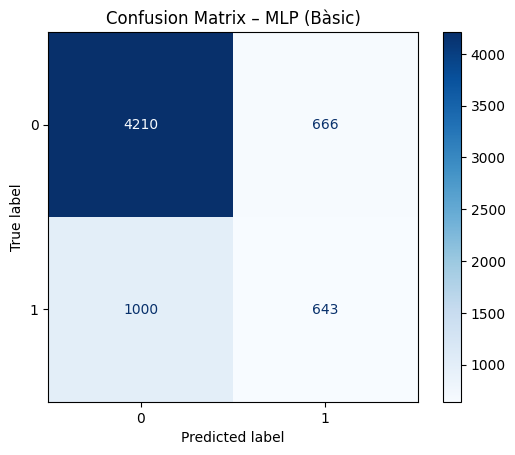

In [10]:
# Model base
mlp_b = MLPClassifier(
    activation="relu",
    solver="adam",
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=1e-4,
    max_iter=500,
    random_state=42
)

# Pipeline preprocessament + model
pipeline_mlp_basic = Pipeline(steps=[
    ("preprocess", preprocessor_basic),
    ("model", mlp_b)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cerca d'hiperparàmetres
param_grid_mlp_b = {
    "model__hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "model__alpha":              [1e-3, 5e-3],
    "model__learning_rate_init": [1e-4, 5e-4, 1e-3],
}

grid_mlp_basic = GridSearchCV(
    pipeline_mlp_basic,
    param_grid=param_grid_mlp_b,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
    verbose=1,
    error_score="raise"
)
grid_mlp_basic.fit(X_train_val_basic, y_train_val_basic)

# Resultats de la validació creuada
print(f"Millors paràmetres: {grid_mlp_basic.best_params_}")
print(f"Millor CV ROC AUC:  {grid_mlp_basic.best_score_:.4f}")

best_mlp_basic = grid_mlp_basic.best_estimator_
mlp_proba_basic = best_mlp_basic.predict_proba(X_test_basic)[:, 1]
y_pred_mlp_basic = best_mlp_basic.predict(X_test_basic)
auc_mlp_basic = roc_auc_score(y_test_basic, mlp_proba_basic)
cm_mlp_basic = confusion_matrix(y_test_basic, y_pred_mlp_basic)

print(f"\nTest ROC AUC: {auc_mlp_basic:.4f}")
print(f"Confusion matrix:\n{cm_mlp_basic}")

ConfusionMatrixDisplay(confusion_matrix=cm_mlp_basic).plot(cmap="Blues")
plt.title("Confusion Matrix – MLP (Bàsic)")
plt.show()

## Corbes ROC AUC al conjunt de test (Bàsic)

La imatge mostra les corbes ROC dels sis models avaluats sobre el conjunt de test amb el conjunt de features bàsiques: LinearSVC, MLP, Logistic Regression L2, Logistic Regression L1, Decision Tree i Random Forest. Tots es comparen respecte al classificador aleatori per valorar la seva capacitat discriminativa.
La comparació visual de les corbes i dels valors AUC permet identificar quin model manté el millor equilibri entre sensibilitat i especificitat en el conjunt de test bàsic.
Aquesta figura resumeix el rendiment relatiu de tots els models binaris entrenats amb features bàsiques.

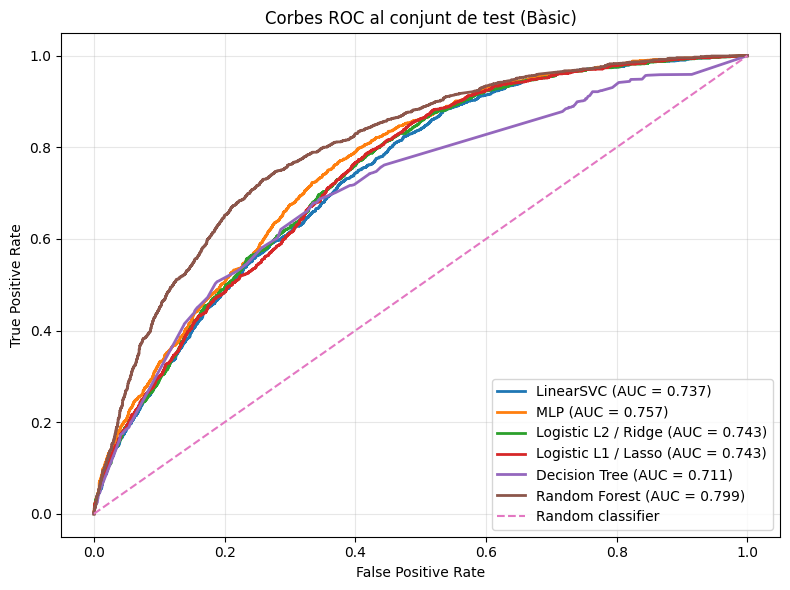

In [11]:
# ROC punts per a cada model
fpr_svm_b, tpr_svm_b, _ = roc_curve(y_test_basic, svm_scores_basic)
fpr_mlp_b, tpr_mlp_b, _ = roc_curve(y_test_basic, mlp_proba_basic)
fpr_l2_b,  tpr_l2_b,  _ = roc_curve(y_test_basic, l2_proba_basic)
fpr_l1_b,  tpr_l1_b,  _ = roc_curve(y_test_basic, l1_proba_basic)
fpr_dt_b,  tpr_dt_b,  _ = roc_curve(y_test_basic, dt_proba_basic)
fpr_rf_b,  tpr_rf_b,  _ = roc_curve(y_test_basic, rf_proba_basic)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(fpr_svm_b, tpr_svm_b, linewidth=2, label=f"LinearSVC (AUC = {auc_svm_basic:.3f})")
plt.plot(fpr_mlp_b, tpr_mlp_b, linewidth=2, label=f"MLP (AUC = {auc_mlp_basic:.3f})")
plt.plot(fpr_l2_b,  tpr_l2_b,  linewidth=2, label=f"Logistic L2 / Ridge (AUC = {auc_l2_basic:.3f})")
plt.plot(fpr_l1_b,  tpr_l1_b,  linewidth=2, label=f"Logistic L1 / Lasso (AUC = {auc_l1_basic:.3f})")
plt.plot(fpr_dt_b,  tpr_dt_b,  linewidth=2, label=f"Decision Tree (AUC = {auc_dt_basic:.3f})")
plt.plot(fpr_rf_b,  tpr_rf_b,  linewidth=2, label=f"Random Forest (AUC = {auc_rf_basic:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Corbes ROC al conjunt de test (Bàsic)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretabilitat (SHAP)

Anàlisi d'interpretabilitat dels sis models entrenats mitjançant 
valors SHAP.

### Models lineals

Càlcul dels valors SHAP per als tres models lineals mitjançant 
`LinearExplainer`. Aquesta implementació és exacta i computacionalment 
molt eficient, ja que aprofita els coeficients apresos del model.

SHAP LinearSVC (Bàsic)


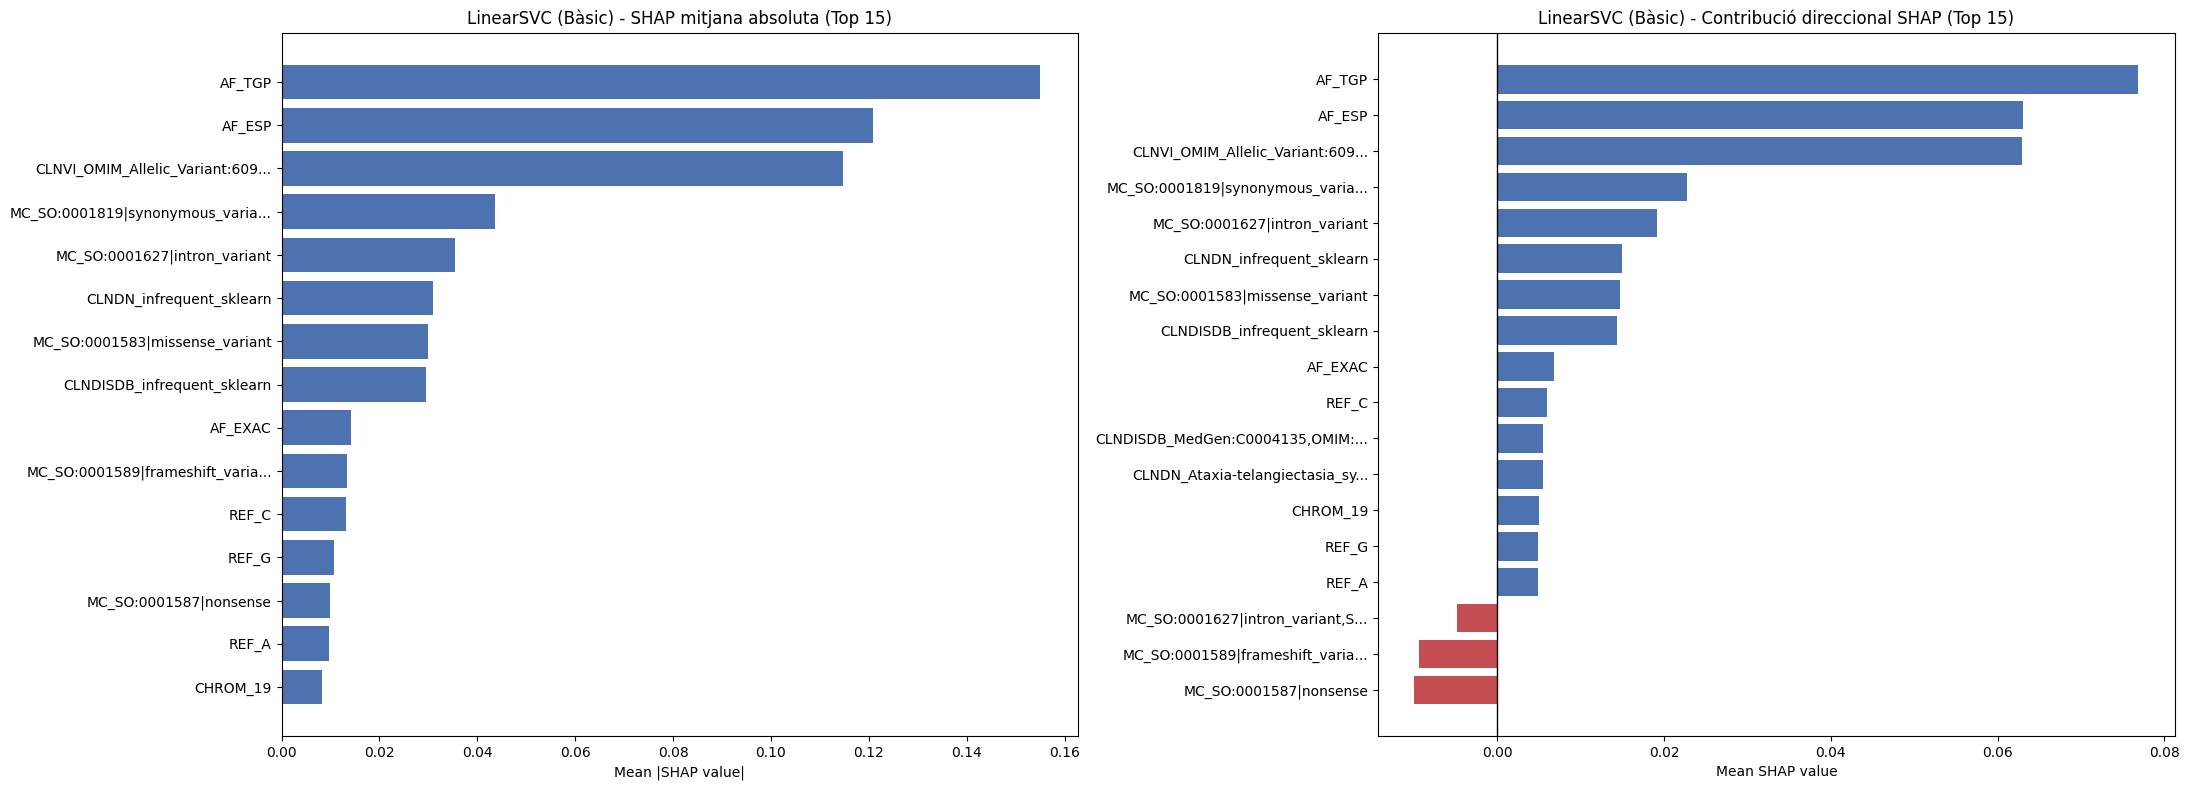

SHAP Ridge L2 (Bàsic)


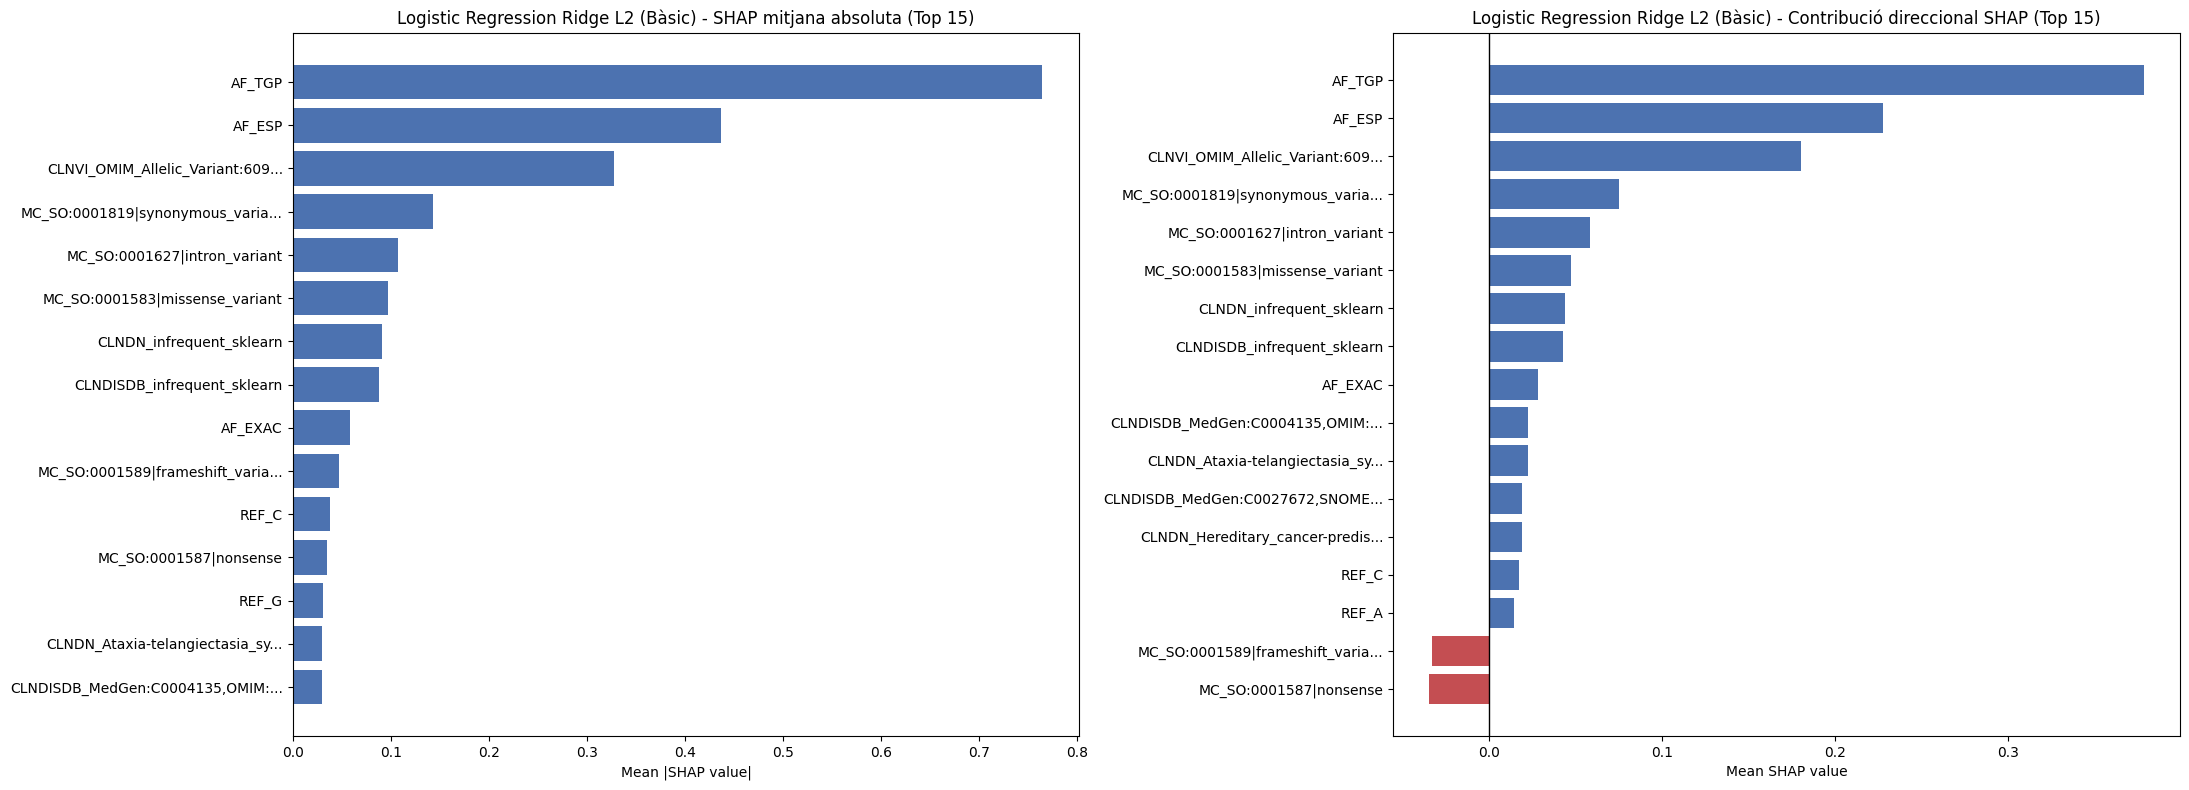

SHAP Lasso L1 (Bàsic)


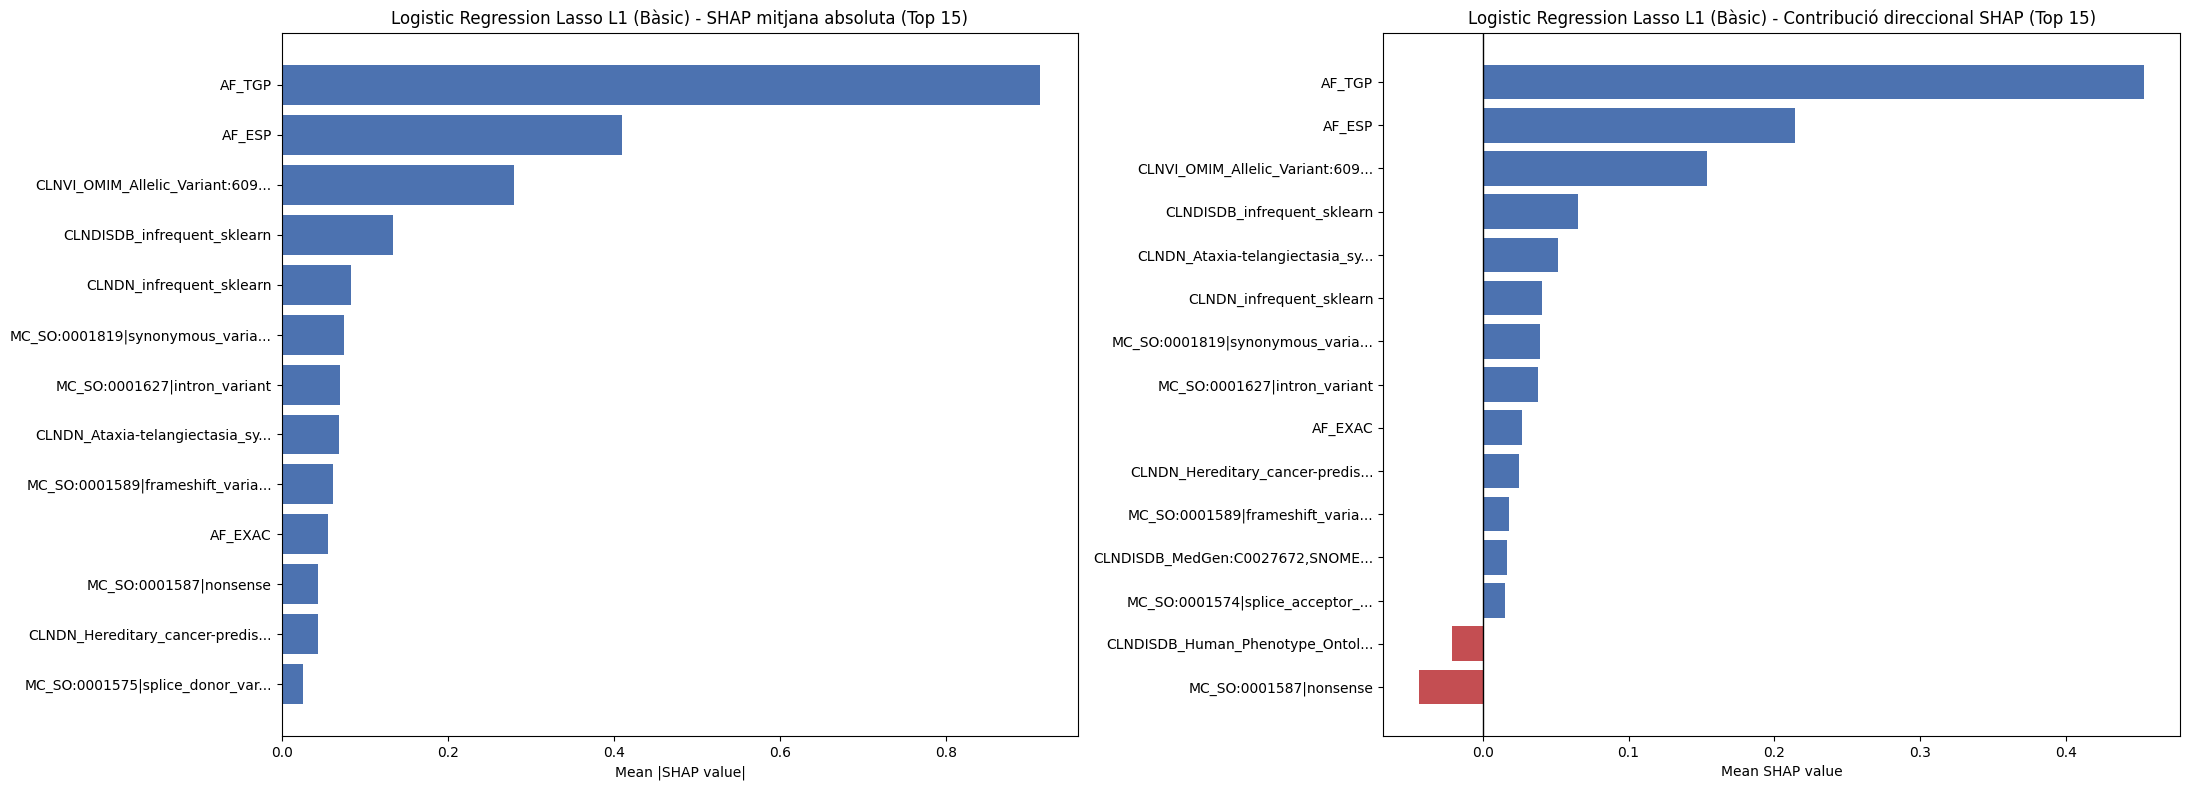

In [12]:
# Transformar el conjunt de test amb el pipeline de preprocessament del millor model lineal (L2) per obtenir les features transformades
X_test_transformed = best_l2_basic.named_steps["preprocess"].transform(X_test_basic)
feature_names = best_l2_basic.named_steps["preprocess"].get_feature_names_out()

# Explainers per als tres models lineals
explainer_svm_b = shap.LinearExplainer(best_svm_basic.named_steps["model"], X_test_transformed)
explainer_l2_b  = shap.LinearExplainer(best_l2_basic.named_steps["model"],  X_test_transformed)
explainer_l1_b  = shap.LinearExplainer(best_l1_basic.named_steps["model"],  X_test_transformed)

# Calcular els valors SHAP per al conjunt de test transformats
shap_values_svm_b = explainer_svm_b.shap_values(X_test_transformed)
shap_values_l2_b  = explainer_l2_b.shap_values(X_test_transformed)
shap_values_l1_b  = explainer_l1_b.shap_values(X_test_transformed)


def clean_feature_name(name, max_len=30):
    """Neteja els noms de les features per a visualització"""
    name = name.replace("cat__", "").replace("num__", "")
    if len(name) > max_len:
        name = name[:max_len] + "..."
    return name


def plot_shap_linear(shap_values, feature_names, title_prefix, top_k=15):
    """Plota les importàncies SHAP per a models lineals, mostrant tant la magnitud com la direcció de la contribució"""
    mean_abs = np.abs(shap_values).mean(axis=0)
    mean_pos = np.where(shap_values > 0, shap_values, 0).mean(axis=0)
    mean_neg = np.where(shap_values < 0, shap_values, 0).mean(axis=0)

    shap_df = pd.DataFrame({
        "feature":       [clean_feature_name(f) for f in feature_names],
        "mean_abs_shap": mean_abs,
        "mean_pos_shap": mean_pos,
        "mean_neg_shap": mean_neg
    })

    top_abs = shap_df.nlargest(top_k, "mean_abs_shap").copy()
    top_pos = shap_df.nlargest(top_k, "mean_pos_shap").copy()
    top_neg = shap_df.nsmallest(top_k, "mean_neg_shap").copy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

    # Gràfic 1: Top k per valor absolut
    top_abs_sorted = top_abs.sort_values("mean_abs_shap")
    ax1.barh(top_abs_sorted["feature"], top_abs_sorted["mean_abs_shap"], color="#4C72B0")
    ax1.set_title(f"{title_prefix} - SHAP mitjana absoluta (Top {top_k})")
    ax1.set_xlabel("Mean |SHAP value|")

    # Gràfic 2: Contribució direccional
    plot_df = pd.concat([
        top_pos.assign(direction="Positive")[["feature", "mean_pos_shap", "direction"]]
               .rename(columns={"mean_pos_shap": "signed_shap"}),
        top_neg.assign(direction="Negative")[["feature", "mean_neg_shap", "direction"]]
               .rename(columns={"mean_neg_shap": "signed_shap"})
    ]).drop_duplicates(subset="feature", keep="first").sort_values("signed_shap")

    colors = ["#C44E52" if x < 0 else "#4C72B0" for x in plot_df["signed_shap"]]
    ax2.barh(plot_df["feature"], plot_df["signed_shap"], color=colors)
    ax2.axvline(0, color="black", linewidth=1)
    ax2.set_title(f"{title_prefix} - Contribució direccional SHAP (Top {top_k})")
    ax2.set_xlabel("Mean SHAP value")

    plt.tight_layout()
    plt.show()


print("SHAP LinearSVC (Bàsic)")
plot_shap_linear(shap_values_svm_b, feature_names, "LinearSVC (Bàsic)")

print("SHAP Ridge L2 (Bàsic)")
plot_shap_linear(shap_values_l2_b, feature_names, "Logistic Regression Ridge L2 (Bàsic)")

print("SHAP Lasso L1 (Bàsic)")
plot_shap_linear(shap_values_l1_b, feature_names, "Logistic Regression Lasso L1 (Bàsic)")


### Decision Tree

Càlcul dels valors SHAP mitjançant `TreeExplainer`, que aprofita 
l'estructura de l'arbre per obtenir valors exactes de manera eficient.

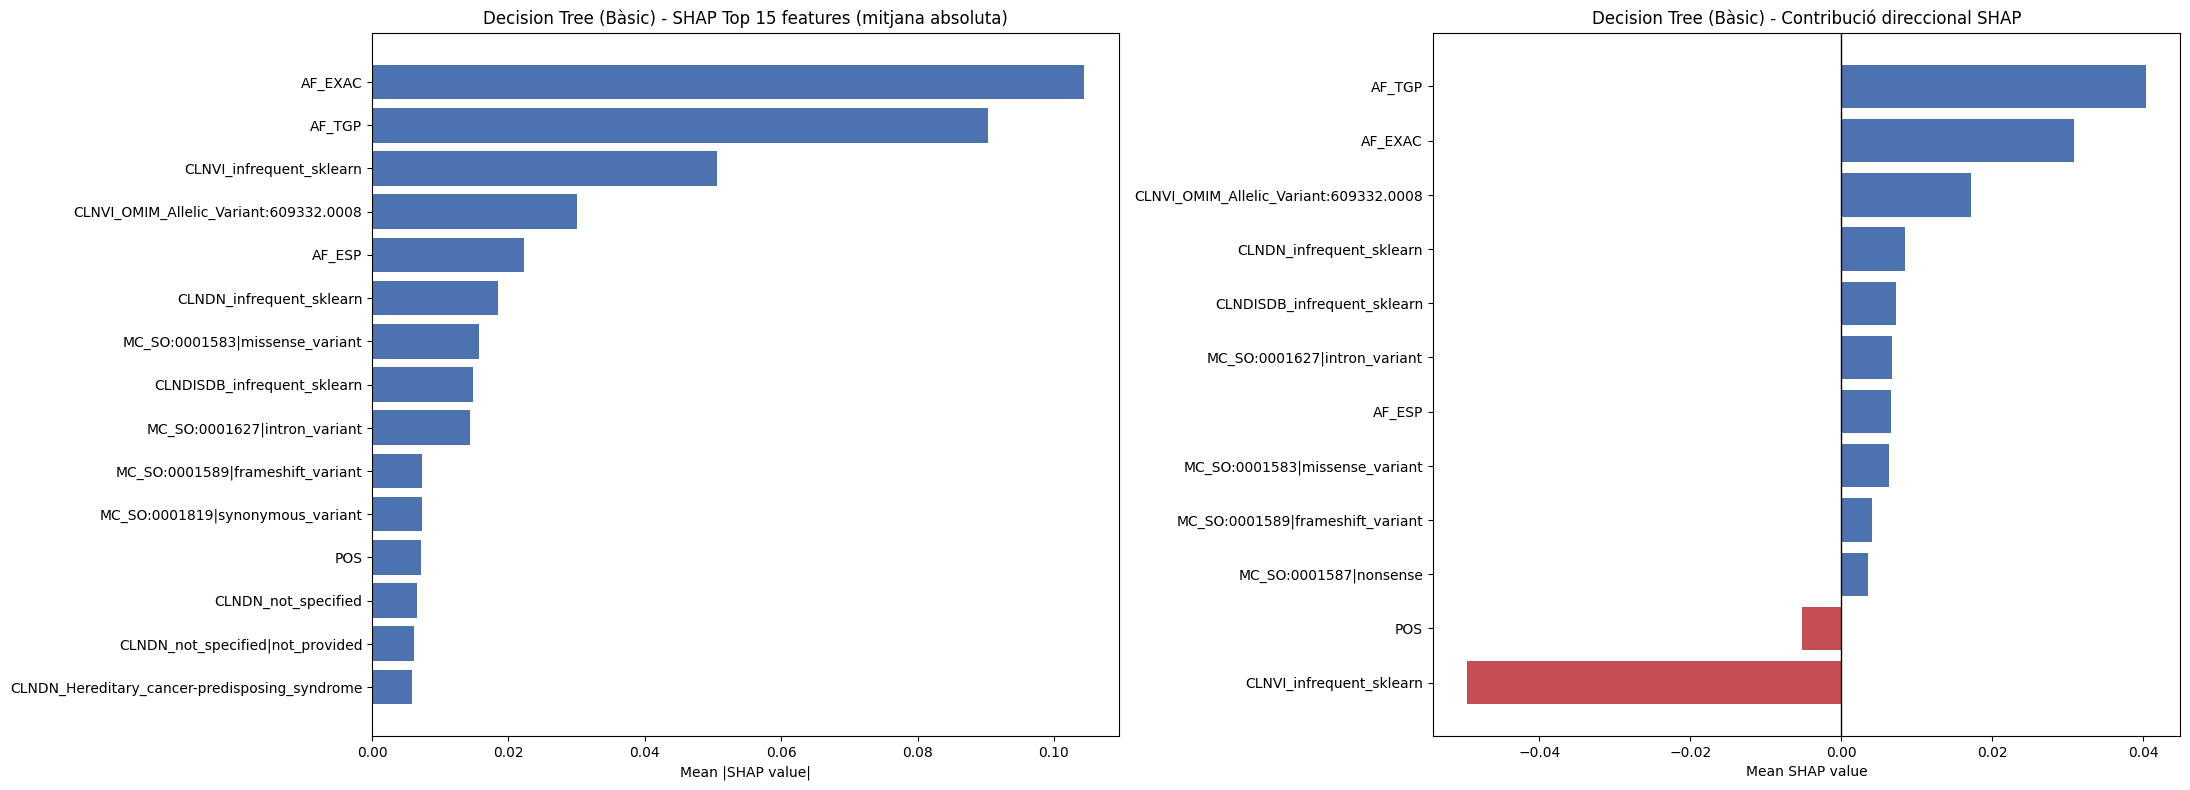

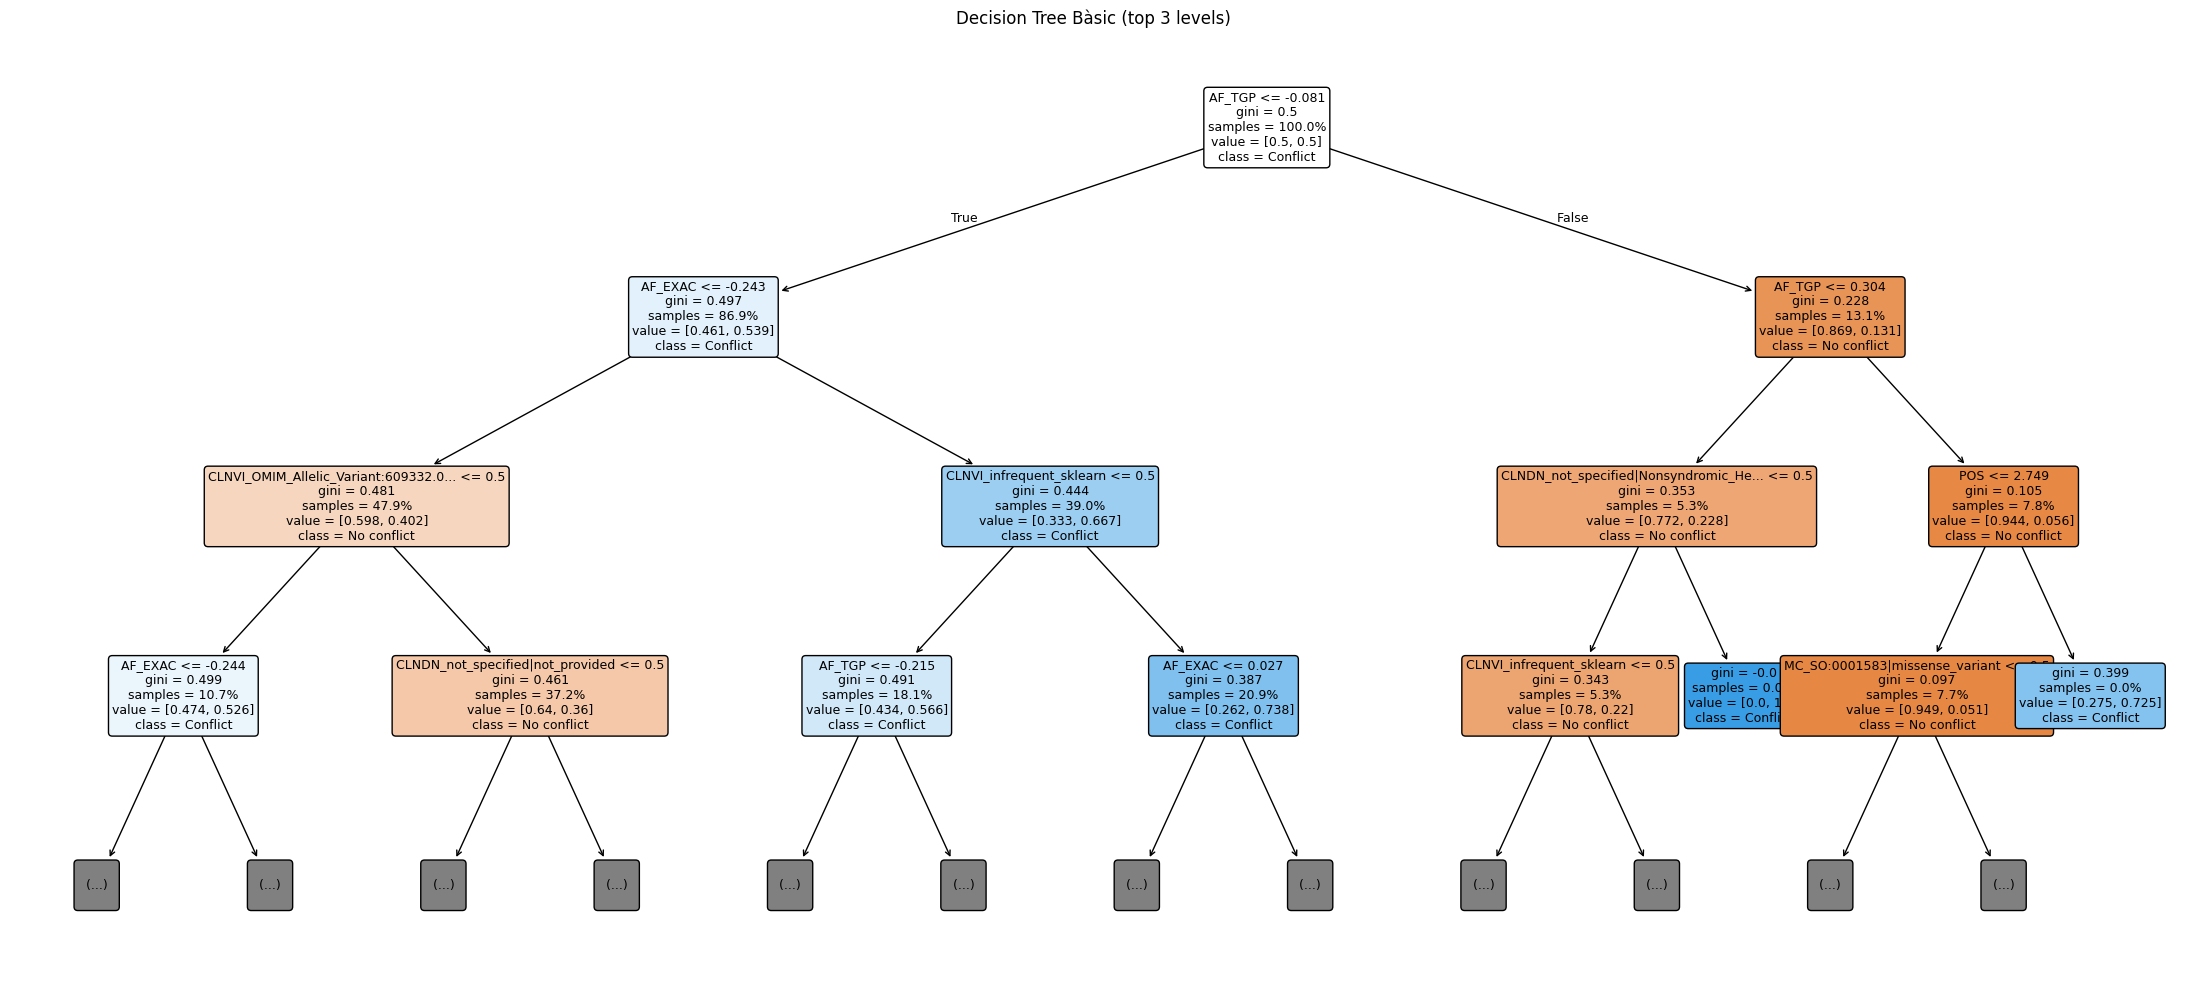

In [13]:
# Per al Decision Tree, utilitzarem un TreeExplainer que pot manejar la naturalesa no lineal i les interaccions del model. Cal transformar el conjunt de test amb el pipeline de preprocessament del millor model de Decision Tree per obtenir les features transformades.
X_test_transformed_dt_b = best_dt_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_transformed_dt_b):
    X_test_transformed_dt_b = X_test_transformed_dt_b.toarray().astype(np.float64)
else:
    X_test_transformed_dt_b = np.array(X_test_transformed_dt_b, dtype=np.float64)

# Obtenir els noms de les features després del preprocessament
feature_names_dt_b = best_dt_basic.named_steps["preprocess"].get_feature_names_out()
explainer_dt_b = shap.TreeExplainer(best_dt_basic.named_steps["model"])
shap_values_dt_b = explainer_dt_b.shap_values(X_test_transformed_dt_b)

sv_dt_b = shap_values_dt_b[1] if isinstance(shap_values_dt_b, list) else shap_values_dt_b

if sv_dt_b.ndim == 3:
    sv_dt_b = sv_dt_b[:, :, 1]

# Calcular les mitjanes per a cada feature
mean_abs_dt_b = np.abs(sv_dt_b).mean(axis=0)
mean_pos_dt_b = np.where(sv_dt_b > 0, sv_dt_b, 0).mean(axis=0)
mean_neg_dt_b = np.where(sv_dt_b < 0, sv_dt_b, 0).mean(axis=0)

shap_full_dt_b = pd.DataFrame({
    "feature":       feature_names_dt_b,
    "mean_abs_shap": mean_abs_dt_b,
    "mean_pos_shap": mean_pos_dt_b,
    "mean_neg_shap": mean_neg_dt_b,
})
shap_full_dt_b["feature"] = shap_full_dt_b["feature"].str.replace("num__", "").str.replace("cat__", "")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# Gràfic 1: Top 15 per valor absolut
shap_df_dt_b = shap_full_dt_b.nlargest(15, "mean_abs_shap").sort_values("mean_abs_shap")
ax1.barh(shap_df_dt_b["feature"], shap_df_dt_b["mean_abs_shap"], color="#4C72B0")
ax1.set_title("Decision Tree (Bàsic) - SHAP Top 15 features (mitjana absoluta)")
ax1.set_xlabel("Mean |SHAP value|")

# Gràfic 2: Contribució direccional
top_k = 10
top_pos_dt_b = shap_full_dt_b.nlargest(top_k, "mean_pos_shap")
top_neg_dt_b = shap_full_dt_b.nsmallest(top_k, "mean_neg_shap")

plot_dt_b = pd.concat([
    top_pos_dt_b[["feature", "mean_pos_shap"]].rename(columns={"mean_pos_shap": "signed_shap"}),
    top_neg_dt_b[["feature", "mean_neg_shap"]].rename(columns={"mean_neg_shap": "signed_shap"})
]).drop_duplicates(subset="feature", keep="first").sort_values("signed_shap")

colors = ["#C44E52" if x < 0 else "#4C72B0" for x in plot_dt_b["signed_shap"]]
ax2.barh(plot_dt_b["feature"], plot_dt_b["signed_shap"], color=colors)
ax2.axvline(0, color="black", linewidth=1)
ax2.set_title("Decision Tree (Bàsic) - Contribució direccional SHAP")
ax2.set_xlabel("Mean SHAP value")

plt.tight_layout()
plt.show()

# Estructura de l'arbre de 3 primers nivells
def shorten_feature_name(name, max_len=35):
    name = name.replace("num__", "").replace("cat__", "")
    return name[:max_len] + "..." if len(name) > max_len else name

feature_names_short_b = [shorten_feature_name(f) for f in feature_names_dt_b]
plt.figure(figsize=(22, 10))
plot_tree(
    best_dt_basic.named_steps["model"],
    feature_names=feature_names_short_b,
    class_names=["No conflict", "Conflict"],
    filled=True, rounded=True, max_depth=3,
    fontsize=9, impurity=True, proportion=True
)
plt.title("Decision Tree Bàsic (top 3 levels)")
plt.tight_layout()
plt.show()

### Random Forest

Càlcul dels valors SHAP mitjançant `TreeExplainer` amb aproximació 
per conjunts d'arbres. S'utilitza `approximate=True` per reduir 
el cost computacional mantenint una estimació fiable.

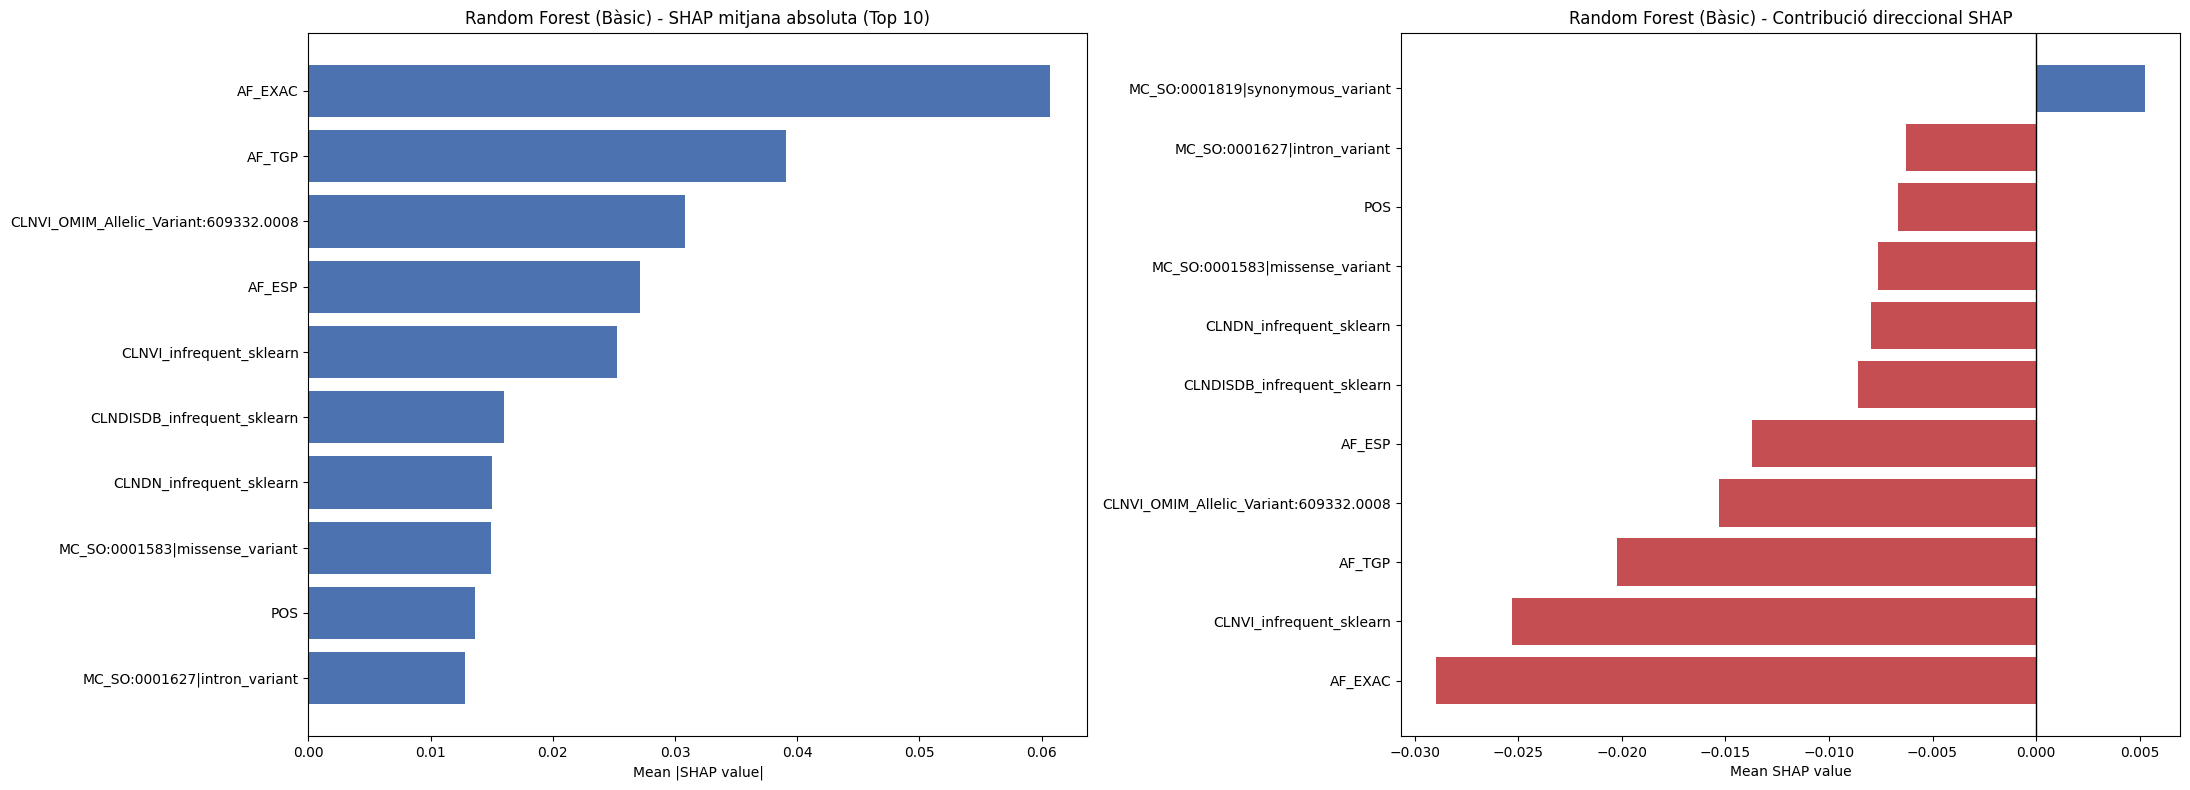

In [14]:
# Per al Random Forest, utilitzarem també un TreeExplainer. Cal transformar el conjunt de test amb el pipeline de preprocessament del millor model de Random Forest per obtenir les features transformades.
X_test_transformed_rf_b = best_rf_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_transformed_rf_b):
    X_test_transformed_rf_b = X_test_transformed_rf_b.toarray().astype(np.float64)
else:
    X_test_transformed_rf_b = np.array(X_test_transformed_rf_b, dtype=np.float64)

# Obtenir els noms de les features després del preprocessament
rf_model_b = best_rf_basic.named_steps["model"]
feature_names_rf_b = best_rf_basic.named_steps["preprocess"].get_feature_names_out()

# Calcular els valors SHAP per al Random Forest
explainer_rf_b = shap.TreeExplainer(rf_model_b)
shap_values_rf_b = explainer_rf_b.shap_values(
    X_test_transformed_rf_b,
    approximate=True,
    check_additivity=False
)

if isinstance(shap_values_rf_b, list):
    sv_rf_b = shap_values_rf_b[1]
else:
    sv_rf_b = shap_values_rf_b[:, :, 1]

# Calcular les mitjanes per a cada feature
mean_abs_shap = np.abs(sv_rf_b).mean(axis=0)
mean_pos_shap = np.where(sv_rf_b > 0, sv_rf_b, 0).mean(axis=0)
mean_neg_shap = np.where(sv_rf_b < 0, sv_rf_b, 0).mean(axis=0)

# Crear DataFrame per a les importàncies SHAP del Random Forest
rf_shap_df_b = pd.DataFrame({
    "feature":       feature_names_rf_b,
    "mean_abs_shap": mean_abs_shap,
    "mean_pos_shap": mean_pos_shap,
    "mean_neg_shap": mean_neg_shap
})
rf_shap_df_b["feature"] = rf_shap_df_b["feature"].str.replace("num__", "").str.replace("cat__", "")

top_k = 10
top_abs_rf_b = rf_shap_df_b.nlargest(top_k, "mean_abs_shap").copy()
top_pos_rf_b = rf_shap_df_b.nlargest(top_k, "mean_pos_shap").copy()
top_neg_rf_b = rf_shap_df_b.nsmallest(top_k, "mean_neg_shap").copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# Gràfic 1: Top k per valor absolut
top_abs_sorted = top_abs_rf_b.sort_values("mean_abs_shap")
ax1.barh(top_abs_sorted["feature"], top_abs_sorted["mean_abs_shap"], color="#4C72B0")
ax1.set_title(f"Random Forest (Bàsic) - SHAP mitjana absoluta (Top {top_k})")
ax1.set_xlabel("Mean |SHAP value|")

# Gràfic 2: Contribució direccional
plot_rf_b = pd.concat([
    top_pos_rf_b.assign(direction="Positive (classe 1)")[["feature", "mean_pos_shap", "direction"]]
        .rename(columns={"mean_pos_shap": "signed_shap"}),
    top_neg_rf_b.assign(direction="Negative (classe 0)")[["feature", "mean_neg_shap", "direction"]]
        .rename(columns={"mean_neg_shap": "signed_shap"})
]).sort_values("signed_shap").drop_duplicates(subset="feature", keep="first")

colors = ["#C44E52" if x < 0 else "#4C72B0" for x in plot_rf_b["signed_shap"]]
ax2.barh(plot_rf_b["feature"], plot_rf_b["signed_shap"], color=colors)
ax2.axvline(0, color="black", linewidth=1)
ax2.set_title("Random Forest (Bàsic) - Contribució direccional SHAP")
ax2.set_xlabel("Mean SHAP value")

plt.tight_layout()
plt.show()

### MLP

Càlcul dels valors SHAP mitjançant `KernelExplainer`, l'únic 
mètode aplicable a xarxes neuronals. S'utilitza un background 
de 30 centroides obtinguts amb k-means sobre el conjunt d'entrenament.

X_shap_sample shape: (6519, 948)


100%|██████████| 6519/6519 [01:42<00:00, 63.75it/s]


SHAP values shape: (6519, 948)


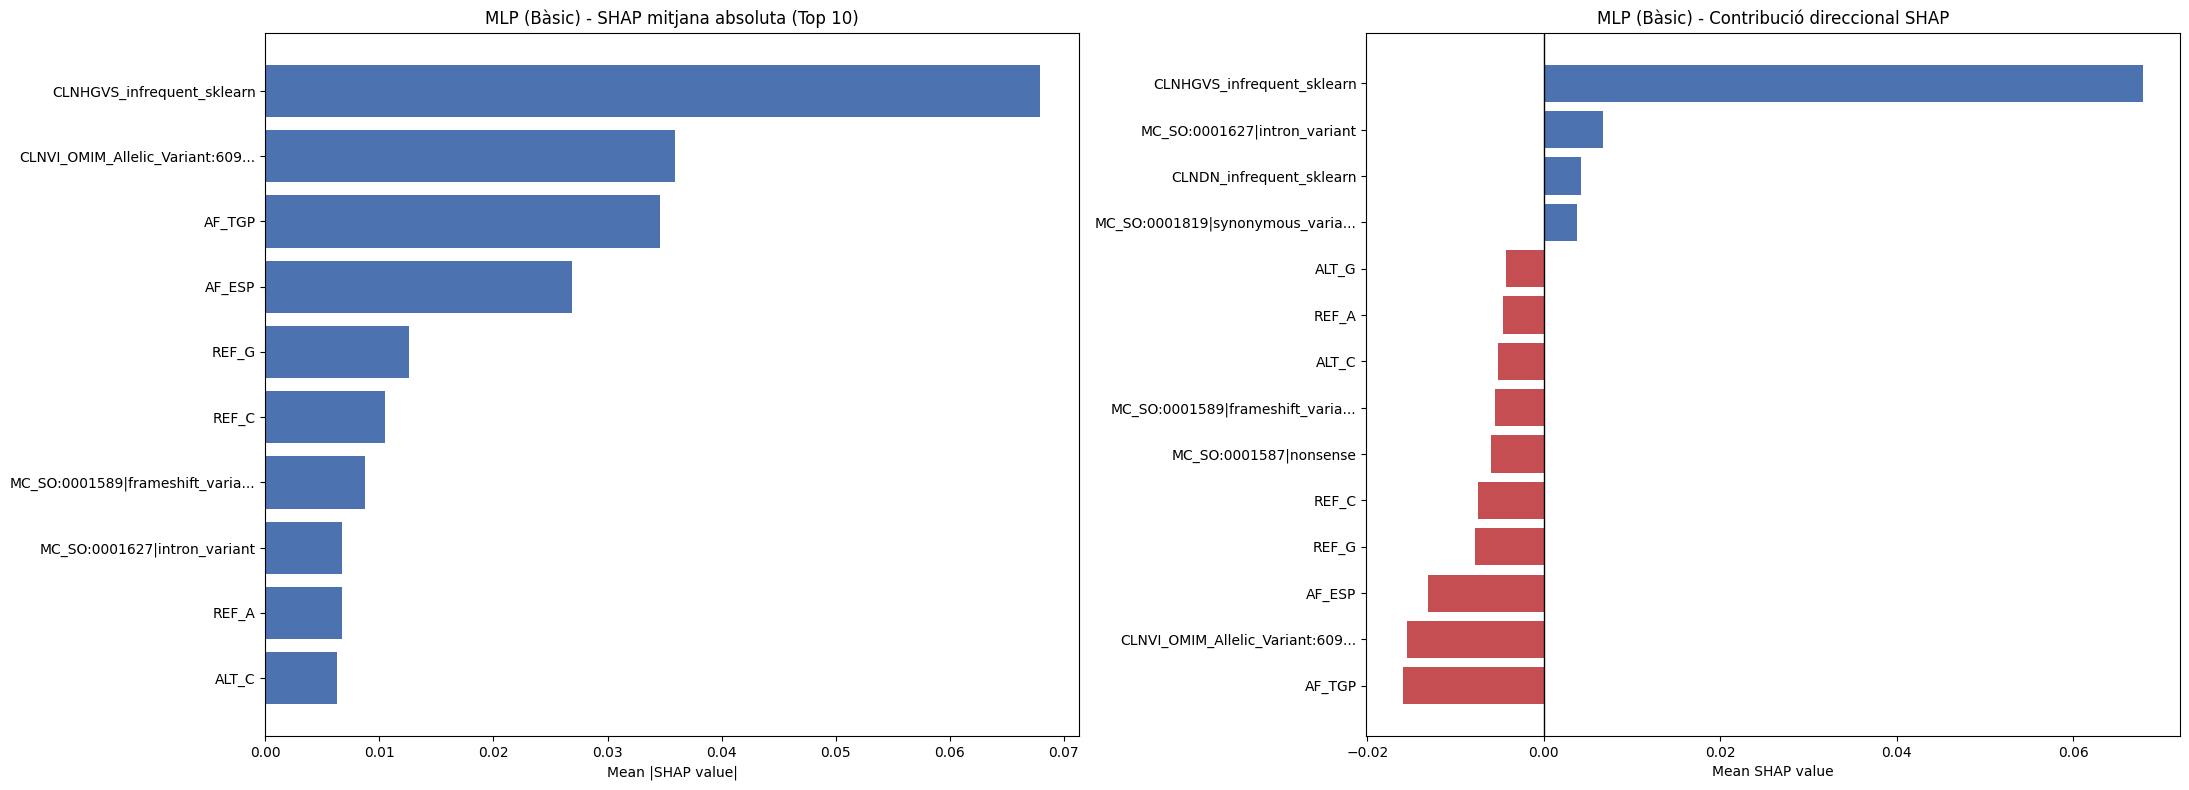

In [15]:
# S'han suprimit els warnings de tipus RuntimeWarning (overflow, divide by zero, etc.)
# ja que són habituals en Kernel SHAP degut a la resolució de sistemes lineals en espais
# d'alta dimensionalitat. Aquests warnings no afecten els resultats finals, però poden
# saturar la sortida i dificultar la interpretació dels resultats.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message=".*matmul.*")
warnings.filterwarnings("ignore", message=".*overflow.*")
warnings.filterwarnings("ignore", message=".*divide by zero.*")


# Per al MLP, utilitzarem un KernelExplainer que pot manejar la naturalesa no lineal del model. Cal transformar el conjunt de test amb el pipeline de preprocessament del millor model de MLP per obtenir les features transformades.
X_test_transformed_mlp_b = best_mlp_basic.named_steps["preprocess"].transform(X_test_basic)
if scipy.sparse.issparse(X_test_transformed_mlp_b):
    X_test_transformed_mlp_b = X_test_transformed_mlp_b.toarray().astype(np.float64)
else:
    X_test_transformed_mlp_b = np.array(X_test_transformed_mlp_b, dtype=np.float64)

# Obtenir els noms de les features després del preprocessament
X_train_transformed_mlp_b = best_mlp_basic.named_steps["preprocess"].transform(X_train_val_basic)
if scipy.sparse.issparse(X_train_transformed_mlp_b):
    X_train_transformed_mlp_b = X_train_transformed_mlp_b.toarray().astype(np.float64)
else:
    X_train_transformed_mlp_b = np.array(X_train_transformed_mlp_b, dtype=np.float64)

# Obtenir els noms de les features després del preprocessament
feature_names_mlp_b = best_mlp_basic.named_steps["preprocess"].get_feature_names_out()
mlp_model_b = best_mlp_basic.named_steps["model"]

background_b = shap.kmeans(X_train_transformed_mlp_b, 30)

print("X_shap_sample shape:", X_test_transformed_mlp_b.shape)

explainer_mlp_b = shap.KernelExplainer(
    lambda x: mlp_model_b.predict_proba(x)[:, 1],
    background_b
)

shap_values_mlp_b = explainer_mlp_b.shap_values(X_test_transformed_mlp_b, nsamples=100)
shap_values_mlp_b = np.array(shap_values_mlp_b, dtype=np.float64)

print("SHAP values shape:", shap_values_mlp_b.shape)

# Calcular les mitjanes per a cada feature
mean_abs_shap = np.abs(shap_values_mlp_b).mean(axis=0)
mean_pos_shap = np.where(shap_values_mlp_b > 0, shap_values_mlp_b, 0).mean(axis=0)
mean_neg_shap = np.where(shap_values_mlp_b < 0, shap_values_mlp_b, 0).mean(axis=0)

mlp_shap_df_b = pd.DataFrame({
    "feature":       [clean_feature_name(f) for f in feature_names_mlp_b],
    "mean_abs_shap": mean_abs_shap,
    "mean_pos_shap": mean_pos_shap,
    "mean_neg_shap": mean_neg_shap
})

top_k = 10
top_abs_mlp_b = mlp_shap_df_b.nlargest(top_k, "mean_abs_shap").copy()
top_pos_mlp_b = mlp_shap_df_b.nlargest(top_k, "mean_pos_shap").copy()
top_neg_mlp_b = mlp_shap_df_b.nsmallest(top_k, "mean_neg_shap").copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# Gràfic 1: Top k per valor absolut
top_abs_sorted = top_abs_mlp_b.sort_values("mean_abs_shap")
ax1.barh(top_abs_sorted["feature"], top_abs_sorted["mean_abs_shap"], color="#4C72B0")
ax1.set_title(f"MLP (Bàsic) - SHAP mitjana absoluta (Top {top_k})")
ax1.set_xlabel("Mean |SHAP value|")

# Gràfic 2: Contribució direccional
plot_mlp_b = pd.concat([
    top_pos_mlp_b.assign(direction="Positive (classe 1)")[["feature", "mean_pos_shap", "direction"]]
        .rename(columns={"mean_pos_shap": "signed_shap"}),
    top_neg_mlp_b.assign(direction="Negative (classe 0)")[["feature", "mean_neg_shap", "direction"]]
        .rename(columns={"mean_neg_shap": "signed_shap"})
]).sort_values("signed_shap").drop_duplicates(subset="feature", keep="first")

colors = ["#C44E52" if x < 0 else "#4C72B0" for x in plot_mlp_b["signed_shap"]]
ax2.barh(plot_mlp_b["feature"], plot_mlp_b["signed_shap"], color=colors)
ax2.axvline(0, color="black", linewidth=1)
ax2.set_title("MLP (Bàsic) - Contribució direccional SHAP")
ax2.set_xlabel("Mean SHAP value")

plt.tight_layout()
plt.show()

## Comparació Interpretabilitat entre models (Bàsic)

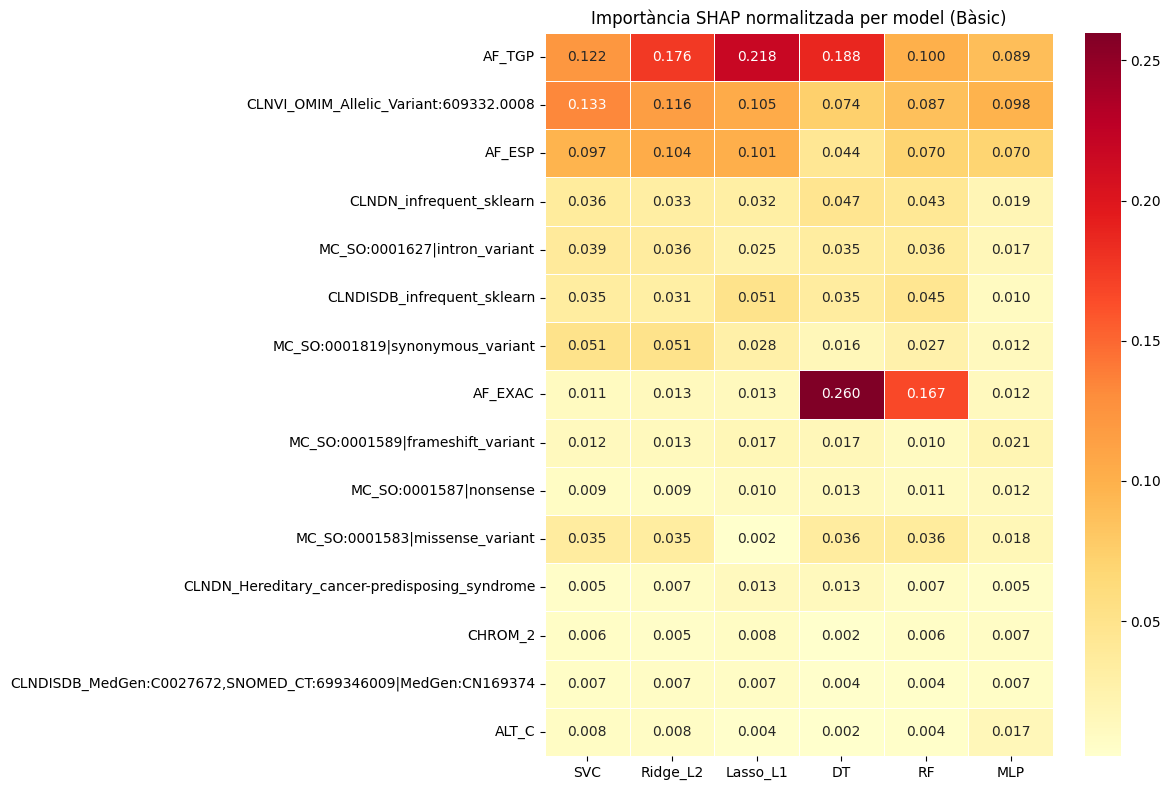

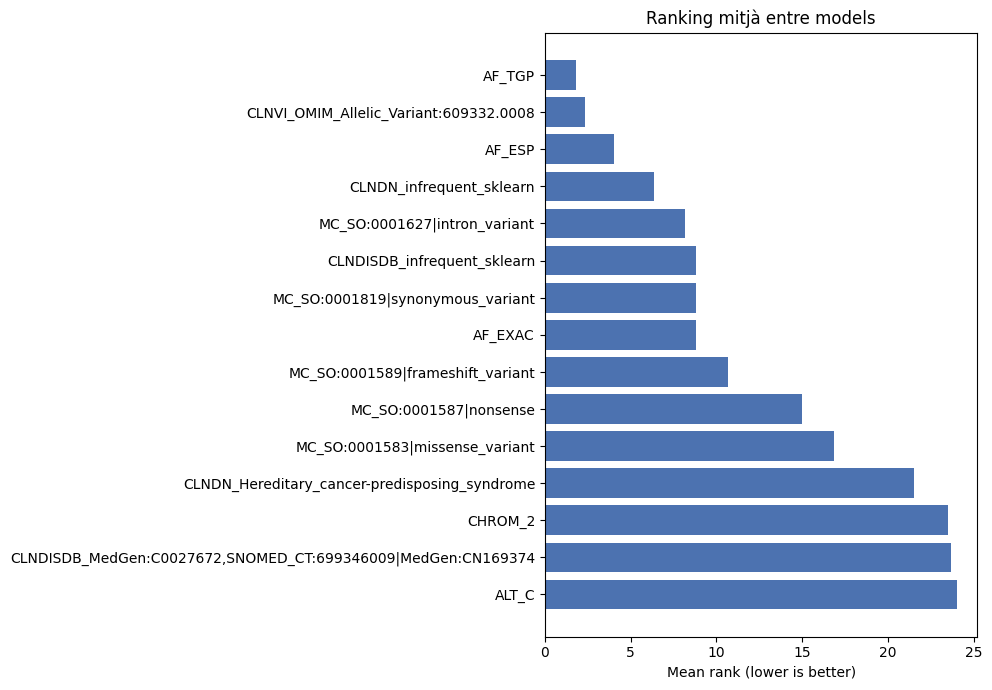

In [ ]:
# Comparativa de les importàncies SHAP entre models per al conjunt bàsic
sv_svm_b = shap_values_svm_b if not isinstance(shap_values_svm_b, list) else shap_values_svm_b[1]
sv_l2_b = shap_values_l2_b if not isinstance(shap_values_l2_b, list) else shap_values_l2_b[1]
sv_l1_b = shap_values_l1_b if not isinstance(shap_values_l1_b, list) else shap_values_l1_b[1]

if isinstance(shap_values_rf_b, list):
    sv_rf_b_meta = shap_values_rf_b[1]
else:
    sv_rf_b_meta = shap_values_rf_b[:, :, 1] if shap_values_rf_b.ndim == 3 else shap_values_rf_b

sv_mlp_b = shap_values_mlp_b if shap_values_mlp_b.ndim == 2 else shap_values_mlp_b[:, :, 1]


# Funció per normalitzar els valors SHAP per a cada model i obtenir una importància relativa entre models
def get_normalized_shap(sv, feature_names):
    abs_sv = np.abs(sv)
    total_per_sample = abs_sv.sum(axis=1, keepdims=True)
    total_per_sample = np.where(total_per_sample == 0, 1, total_per_sample)
    normalized = abs_sv / total_per_sample
    mean_normalized = normalized.mean(axis=0)
    clean_names = [f.replace("num__", "").replace("cat__", "") for f in feature_names]
    return pd.Series(mean_normalized, index=clean_names)

# Obtenir les importàncies SHAP normalitzades per a cada model
importance_svm_b = get_normalized_shap(sv_svm_b,     feature_names)
importance_l2_b  = get_normalized_shap(sv_l2_b,      feature_names)
importance_l1_b  = get_normalized_shap(sv_l1_b,      feature_names)
importance_dt_b  = get_normalized_shap(sv_dt_b,      feature_names_dt_b)
importance_rf_b  = get_normalized_shap(sv_rf_b_meta, feature_names_rf_b)
importance_mlp_b = get_normalized_shap(sv_mlp_b,     feature_names_mlp_b)

# Crear un DataFrame per comparar les importàncies SHAP entre models
meta_df_b = pd.DataFrame({
    "SVC":      importance_svm_b,
    "Ridge_L2": importance_l2_b,
    "Lasso_L1": importance_l1_b,
    "DT":       importance_dt_b,
    "RF":       importance_rf_b,
    "MLP":      importance_mlp_b,
}).fillna(0)

meta_df_b["mean_across_models"] = meta_df_b.mean(axis=1)

for col in ["SVC", "Ridge_L2", "Lasso_L1", "DT", "RF", "MLP"]:
    meta_df_b[f"rank_{col}"] = meta_df_b[col].rank(ascending=False).astype(int)

meta_df_b["mean_rank"] = meta_df_b[["rank_SVC", "rank_Ridge_L2", "rank_Lasso_L1", "rank_DT", "rank_RF", "rank_MLP"]].mean(axis=1)

top15_b = meta_df_b.sort_values("mean_rank").head(15)

# Visualització de les importàncies SHAP normalitzades per als 15 features més importants segons el ranking mitjà
top15_heat_b = top15_b[["SVC", "Ridge_L2", "Lasso_L1", "DT", "RF", "MLP"]]
plt.figure(figsize=(12, 8))
sns.heatmap(top15_heat_b, annot=True, fmt=".3f", cmap="YlOrRd", linewidths=0.5)
plt.title("Importància SHAP normalitzada per model (Bàsic)")
plt.tight_layout()
plt.show()

top15_rank_b = meta_df_b.sort_values("mean_rank").head(15).copy()
top15_rank_b["feature"] = top15_rank_b.index

plt.figure(figsize=(10, 7))
plt.barh(top15_rank_b["feature"][::-1], top15_rank_b["mean_rank"][::-1], color="#4C72B0")
plt.title("Ranking mitjà entre models")
plt.xlabel("Mean rank (lower is better)")
plt.tight_layout()
plt.show()


In [17]:
import pickle
import os

pkl_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'results_annotated.pkl')
with open(pkl_path, 'rb') as f:
    _ann = pickle.load(f)

# Reconstruim objectes simples per compatibilitat amb la cel·la de comparació
class _Score:
    def __init__(self, v): self.best_score_ = v

grid_svm               = _Score(_ann['svm_cv'])
auc_svm                = _ann['svm_auc']
grid_mlp               = _Score(_ann['mlp_cv'])
auc_mlp                = _ann['mlp_auc']
grid_l2                = _Score(_ann['l2_cv'])
auc_l2                 = _ann['l2_auc']
grid_l1                = _Score(_ann['l1_cv'])
auc_l1                 = _ann['l1_auc']
grid_dt_binary         = _Score(_ann['dt_cv'])
auc_dt_binary          = _ann['dt_auc']
random_search_rf_binary = _Score(_ann['rf_cv'])
auc_rf_binary          = _ann['rf_auc']

print('Resultats annotated carregats correctament')

Resultats annotated carregats correctament


## Comparació Models – Annotated vs Bàsic

,Model,Dataset,CV AUC,Test AUC
0,LinearSVC,Annotated,0.7418,0.7431
1,MLP,Annotated,0.7595,0.7633
2,Logistic L2,Annotated,0.7488,0.7493
3,Logistic L1,Annotated,0.7429,0.7474
4,Decision Tree,Annotated,0.7579,0.7196
5,Random Forest,Annotated,0.8140,0.8269
6,LinearSVC,Basic,0.7397,0.7373
7,MLP,Basic,0.7657,0.7570
8,Logistic L2,Basic,0.7459,0.7432
9,Logistic L1,Basic,0.7440,0.7425


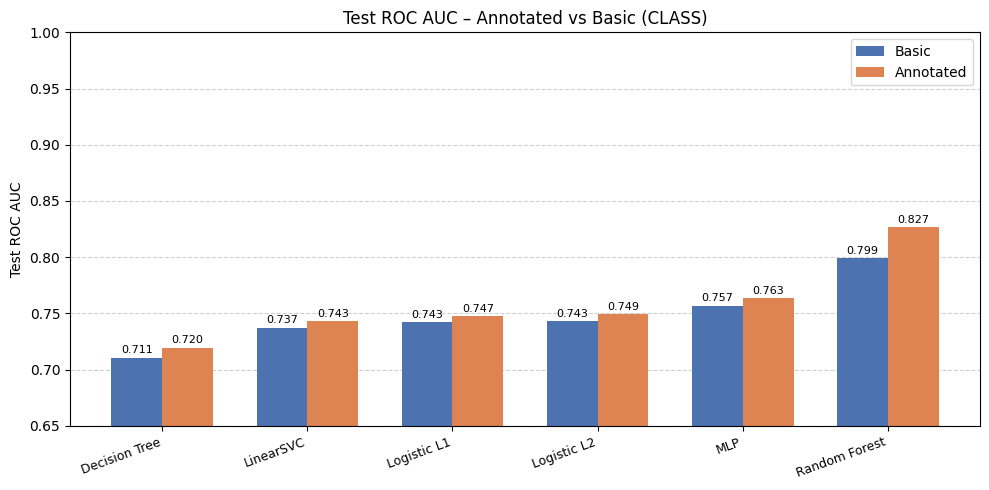

In [18]:
models_comparison = [
    ("LinearSVC",     "Annotated", grid_svm.best_score_,                auc_svm),
    ("MLP",           "Annotated", grid_mlp.best_score_,                auc_mlp),
    ("Logistic L2",   "Annotated", grid_l2.best_score_,                 auc_l2),
    ("Logistic L1",   "Annotated", grid_l1.best_score_,                 auc_l1),
    ("Decision Tree", "Annotated", grid_dt_binary.best_score_,          auc_dt_binary),
    ("Random Forest", "Annotated", random_search_rf_binary.best_score_, auc_rf_binary),
    ("LinearSVC",     "Basic",     grid_svm_basic.best_score_,                auc_svm_basic),
    ("MLP",           "Basic",     grid_mlp_basic.best_score_,                auc_mlp_basic),
    ("Logistic L2",   "Basic",     grid_l2_basic.best_score_,                 auc_l2_basic),
    ("Logistic L1",   "Basic",     grid_l1_basic.best_score_,                 auc_l1_basic),
    ("Decision Tree", "Basic",     grid_dt_binary_basic.best_score_,          auc_dt_basic),
    ("Random Forest", "Basic",     random_search_rf_binary_basic.best_score_,  auc_rf_basic),
]

df_comp = pd.DataFrame(models_comparison, columns=["Model", "Dataset", "CV AUC", "Test AUC"])
df_comp["CV AUC"]   = df_comp["CV AUC"].round(4)
df_comp["Test AUC"] = df_comp["Test AUC"].round(4)
display(df_comp)

pivot = df_comp.pivot(index="Model", columns="Dataset", values="Test AUC")

model_names = pivot.index.tolist()
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, pivot["Basic"],     width, label="Basic",     color="#4C72B0")
ax.bar(x + width/2, pivot["Annotated"], width, label="Annotated", color="#DD8452")

for i, (b, a) in enumerate(zip(pivot["Basic"], pivot["Annotated"])):
    ax.text(i - width/2, b + 0.002, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + width/2, a + 0.002, f"{a:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
ax.set_ylim(0.65, 1.00)
ax.set_ylabel("Test ROC AUC")
ax.set_title("Test ROC AUC – Annotated vs Basic (CLASS)")
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()